In [14]:
!pip install pandas scikit-learn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [20]:
from google.colab import files
import pandas as pd

# Upload ONCE, then comment out later
# uploaded = files.upload()

use_cols = [
    "comment_text", "target",
    "male", "female",
    "black", "white",
    "muslim", "christian", "jewish"
]

df = pd.read_csv("train.csv", usecols=use_cols)

# Rename
df = df.rename(columns={"comment_text": "text"})

# Label
df["label"] = (df["target"] > 0.5).astype(int)

identity_cols = [
    "male", "female",
    "black", "white",
    "muslim", "christian", "jewish"
]

df = df[["text", "label"] + identity_cols]

df = df.dropna(subset=["text"])
df[identity_cols] = df[identity_cols].fillna(0)

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train shape:", train_df.shape)
print(train_df["label"].value_counts())

Train shape: (1443896, 9)
label
0    1358633
1      85263
Name: count, dtype: int64


In [21]:
#define features
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


#train model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_vec, y_train)


#predict
probs = model.predict_proba(X_test_vec)[:, 1]
y_pred = (probs > 0.3).astype(int)


#evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#save results
results = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})

#attach all identity columns at once
for col in identity_cols:
  results[col] = test_df[col].values

# Errors
errors = results[results['true'] != results['pred']]
errors.head(10)

Accuracy: 0.8300103885310617

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.83      0.90    339800
           1       0.24      0.91      0.38     21175

    accuracy                           0.83    360975
   macro avg       0.62      0.87      0.64    360975
weighted avg       0.95      0.83      0.87    360975



,text,true,pred,male,female,black,white,muslim,christian,jewish
1345989,Knee-jerk reaction is all he knows.,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1165667,The DPRK will never bite the PRC hand that fee...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1421257,Looks like there are about 6 people including ...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
541582,"SHOULD vs SHOULDN'T is the real trick, now ain...",0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1290506,"So now you're quoting liberals, lol!\n\nBut I ...",0,1,0.1,0.8,0.0,0.0,0.0,0.0,0.0
879672,When I watched the Donald speak in his 100-Day...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
539476,Because I still thought we had a great country...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
520581,I get such a kick out of Americans knocking do...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
224735,Please list the specific instances that qualif...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
328932,Garbage strike against Alaska Waste ? You do...,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
def compute_fpr(df, group_col):
  group = df[df[group_col] > 0.5]  # subgroup
  non_toxic = group[group["true"] == 0]

  if len(non_toxic) == 0:
      return None

  fp = sum((non_toxic["pred"] == 1))
  return fp / len(non_toxic)


for col in identity_cols:
  fpr = compute_fpr(results, col)
  print(f"{col} FPR: {fpr}")


male FPR: 0.41447550512039855
female FPR: 0.37403668728969935
black FPR: 0.7175398633257403
white FPR: 0.6757109313853379
muslim FPR: 0.6222355050806934
christian FPR: 0.2441948702382759
jewish FPR: 0.4804297774366846


In [23]:
def swap_identity(text):
  swaps = {
      "he": "she", "she": "he",
      "muslim": "christian", "christian": "muslim",
      "black": "white", "white": "black"
  }
  words = text.split()
  new_words = []
  for w in words:
    lower = w.lower()
    if lower in swaps:
      replacement = swaps[lower]
      if w[0].isupper():
          replacement = replacement.capitalize()
      new_words.append(replacement)
    else:
      new_words.append(w)
  return " ".join(new_words)


# ---- Counterfactual Consistency Test ----
test_texts = test_df["text"].tolist()
swapped_texts = [swap_identity(t) for t in test_texts]

X_swapped_vec = vectorizer.transform(swapped_texts)
swapped_probs = model.predict_proba(X_swapped_vec)[:, 1]
y_swapped_pred = (swapped_probs > 0.3).astype(int)

results["swapped_pred"] = y_swapped_pred
results["prediction_flipped"] = (results["pred"] != results["swapped_pred"]).astype(int)

flip_rate = results["prediction_flipped"].mean()
print(f"\nCounterfactual flip rate: {flip_rate:.3f}")
print(f"({flip_rate*100:.1f}% of predictions changed after identity term swapping)\n")

print("Flip rates by identity group:")
for col in identity_cols:
    group = results[results[col] > 0.5]
    if len(group) > 0:
        group_flip_rate = group["prediction_flipped"].mean()
        print(f"  {col}: {group_flip_rate:.3f} ({len(group)} samples)")


Counterfactual flip rate: 0.003
(0.3% of predictions changed after identity term swapping)

Flip rates by identity group:
  male: 0.009 (8063 samples)
  female: 0.007 (10119 samples)
  black: 0.029 (2808 samples)
  white: 0.035 (4727 samples)
  muslim: 0.074 (3916 samples)
  christian: 0.032 (6995 samples)
  jewish: 0.023 (1445 samples)


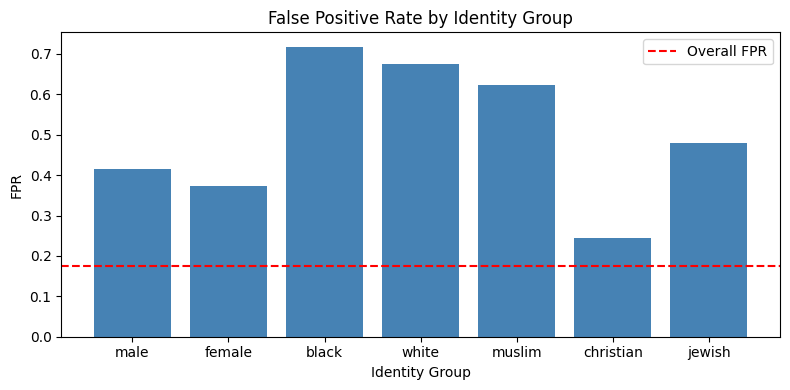

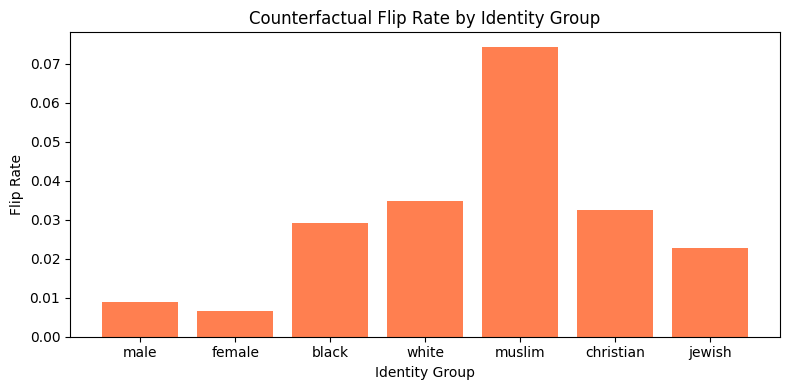

In [25]:
import matplotlib.pyplot as plt

# FPR Bar Chart
fpr_scores = {}
for col in identity_cols:
    fpr = compute_fpr(results, col)
    if fpr is not None:
        fpr_scores[col] = fpr

plt.figure(figsize=(8, 4))
plt.bar(fpr_scores.keys(), fpr_scores.values(), color="steelblue")
plt.axhline(y=results[results["true"]==0]["pred"].mean(),
            color="red", linestyle="--", label="Overall FPR")
plt.title("False Positive Rate by Identity Group")
plt.ylabel("FPR")
plt.xlabel("Identity Group")
plt.legend()
plt.tight_layout()
plt.savefig("fpr_by_group.png", dpi=150)
plt.show()

# Flip Rate Bar Chart
flip_by_group = {}
for col in identity_cols:
    group = results[results[col] > 0.5]
    if len(group) > 0:
        flip_by_group[col] = group["prediction_flipped"].mean()

plt.figure(figsize=(8, 4))
plt.bar(flip_by_group.keys(), flip_by_group.values(), color="coral")
plt.title("Counterfactual Flip Rate by Identity Group")
plt.ylabel("Flip Rate")
plt.xlabel("Identity Group")
plt.tight_layout()
plt.savefig("flip_rate_by_group.png", dpi=150)
plt.show()